In [29]:
# Imports
import numpy as np # For storing data and performing computations
SEED = 57131605 # For deterministic testing

In [23]:
# Parse Data
import email
from email import policy
from pathlib import Path

# Parser
def parse_path(path: Path) -> list[str]:
    out = []
    for file in path.glob('*.txt'):
        with open(file=file, mode='r', encoding='latin-1') as f:
            try:
                message = email.message_from_file(f, policy=policy.default)
                subject = message['subject'] or '' # Get subject message (set to an empty string if not provided)
                body = ""
                if message.is_multipart():
                    for part in message.walk():
                        if part.get_content_type() == 'text/plain':
                            body += part.get_content()
                else:
                    body = message.get_content()
                out.append(subject + " " + body)
            except Exception as e:
                print(f'Failed on {file}: {e}')
                return []
    return out

# Parse folders
spam_emails = parse_path(Path('enron1/spam'))
ham_emails = parse_path(Path('enron1/ham'))

In [24]:
# Clean data
import re

# Transform every email string into a list of words
def tokenize(text: str) -> list[str]:
    text = text.lower() # Standard formatting
    text = re.sub(r'\d+', ' ', text) # Remove digits
    text = re.sub(r'\W+', ' ', text) # Remove other erroneous characters
    return text.split()

# Tokenize email strings
spam_tokens = [t for t in map(tokenize, spam_emails)]
ham_tokens = [t for t in map(tokenize, ham_emails)]

In [25]:
# Bag of Words model

# Finding highest frequency counts
word2count = dict()
for lst in spam_tokens + ham_tokens:
    for token in lst:
        if token in word2count:
            word2count[token] += 1
        else:
            word2count[token] = 1

# HYPERPARAMETER: number of words kept -- N_WORDS
N_WORDS = 2000
import heapq
freq_words = set(heapq.nlargest(N_WORDS, word2count, key=word2count.get))

# Truncate Dictionary:
word2count = {w: word2count[w] for w in word2count if w in freq_words}

# Word to Index
WtoI = {w:i for i, w in enumerate(freq_words)}

# Construct word vectors
xs = np.zeros(shape=(5172, 2000), dtype=float)
ys = np.concatenate((np.zeros(shape=(1500,), dtype=int) - 1, np.zeros(shape=(3672,), dtype=int) + 1))

# Construct Bag of Words vectors
for i, tokens in enumerate(spam_tokens + ham_tokens):
    for token in tokens:
        if token in freq_words:
            xs[i, WtoI[token]] += 1

np.random.seed(SEED)
permut = np.random.permutation(len(xs))

xs = xs[permut]
ys = ys[permut]

# Clip Words -- Later might refine this
xs[xs > 0] = 1
xs /= np.linalg.norm(xs, axis=0, keepdims=True) + 1e-10

# Create datasplits
x_train = xs[:4138]
y_train = ys[:4138]
x_test = xs[4138:4655]
y_test = ys[4138:4655]
x_dev = xs[4655:]
y_dev = ys[4655:]

In [26]:
# Hard Margin Support Vector Machine

# Perform Optimization on Lagrange Multiplier Vector: L
H = np.outer(y_train, y_train) * (x_train @ x_train.T)
H /= H.max() # Scale down matrix to control gradient
H += np.eye(H.shape[0]) * 1e-2 # Reduce eig val spread
def grad_descent(H = H, Y = y_train, iters=int(1e4), epsilon=1e-3):
    L = np.zeros(shape=(len(x_train)), dtype=float)
    for _ in range(iters):
        grad = H @ L - 1
        grad = np.clip(grad, -1000, 1000)
        L -= epsilon * grad # Step
        L = np.clip(L, 0, 1e3) # Enforce Non-Negativity
        L = L - Y * (Y @ L) / (Y @ Y + 1e-10) # Project onto Hyperplane to maintain constraint
    return L
L = grad_descent()

In [ ]:
# Retrieve Weight and bias from Lagrange multiplier vector
W = L * y_train @ x_train
supp_idcs = np.where(L > 1e-5)
B = np.mean([y_train[i] - x_train[i] @ W for i in supp_idcs])

# Define prediction function
def predict(x):
    return np.sign(x @ W + B)

# Make predictions
y_pred = np.zeros(shape=(517,), dtype=float)
for i, t in enumerate(zip(x_test, y_test)):
    x, y = t
    y_pred[i] = predict(x)

# Assess Predictions
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=["Spam", "Ham"]))


              precision    recall  f1-score   support

        Spam       0.65      1.00      0.79       153
         Ham       1.00      0.77      0.87       364

    accuracy                           0.84       517
   macro avg       0.82      0.89      0.83       517
weighted avg       0.90      0.84      0.85       517



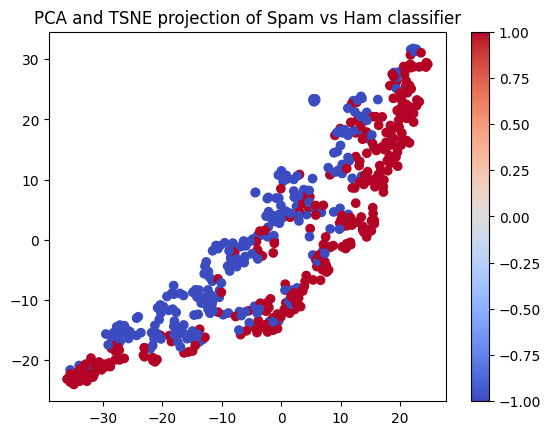

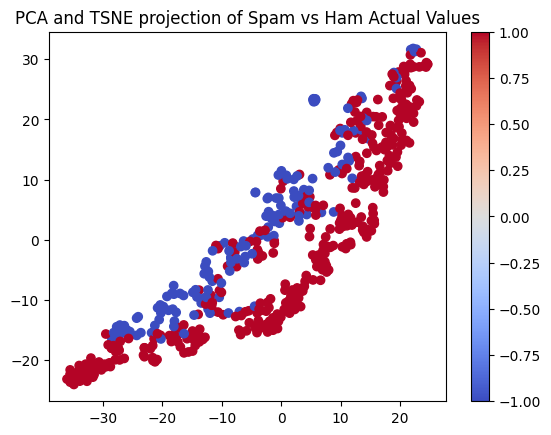

In [28]:
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca = PCA(n_components=2)
x_vis = pca.fit_transform(x_test)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
x_vis = tsne.fit_transform(x_vis)

plt.scatter(x_vis[:, 0], x_vis[:, 1], c=y_pred, cmap='coolwarm')
plt.colorbar()
plt.title('PCA and TSNE projection of Spam vs Ham classifier')
plt.show()

plt.scatter(x_vis[:, 0], x_vis[:, 1], c=y_test, cmap='coolwarm')
plt.colorbar()
plt.title('PCA and TSNE projection of Spam vs Ham Actual Values')
plt.show()